# 01 Data Quality Assessment

This notebook performs a full data quality assessment for `data/CardiacPatientData.csv` without modifying the raw data file.

The assessment includes dataset structure, missingness, duplicates, repeated IDs, descriptive statistics, categorical/binary value distributions, clinical range checks, IQR outlier checks, and basic visualizations saved to `reports/figures/`.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "CardiacPatientData.csv"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
SUMMARY_PATH = REPORTS_DIR / "data_quality_summary.csv"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data path: {DATA_PATH}")
print(f"Figures directory: {FIGURES_DIR}")
print(f"Summary CSV path: {SUMMARY_PATH}")

Data path: c:\Users\shrey\OneDrive\Desktop\Personal Projects\tt\Cardiac-Arrest-Risk-Modeling\data\CardiacPatientData.csv
Figures directory: c:\Users\shrey\OneDrive\Desktop\Personal Projects\tt\Cardiac-Arrest-Risk-Modeling\reports\figures
Summary CSV path: c:\Users\shrey\OneDrive\Desktop\Personal Projects\tt\Cardiac-Arrest-Risk-Modeling\reports\data_quality_summary.csv


## Load data

The raw CSV is read into memory only. This notebook writes derived summary outputs to `reports/` and figures to `reports/figures/`; it does **not** modify or overwrite the raw CSV.

In [2]:
df = pd.read_csv(DATA_PATH)
# Preserve the original in memory dataframe for auditing; all derived objects are copies/summaries.
df_raw = df.copy(deep=True)
df.head()

,ID,SBP,DBP,HR,RR,BT,SpO2,Age,Gender,GCS,Na,K,Cl,Urea,Ceratinine,Alcoholic,Smoke,FHCD,TriageScore,Outcome
0,1,163,95,90,18,98,98,66,1,15,139.0,4.0,105.0,41.0,91.0,1.0,1.0,0.0,3.0,1
1,1,134,85,85,15,98,98,66,1,15,139.0,4.0,105.0,41.0,91.0,1.0,1.0,0.0,3.0,1
2,1,121,77,80,19,98,98,66,1,15,139.0,4.0,105.0,41.0,91.0,1.0,1.0,0.0,3.0,1
3,1,103,78,70,16,98,98,66,1,15,139.0,4.0,105.0,41.0,91.0,1.0,1.0,0.0,3.0,1
4,1,96,70,59,13,98,98,66,1,15,139.0,4.0,105.0,41.0,91.0,1.0,1.0,0.0,3.0,1


## 1. Dataset shape

In [3]:
shape_summary = pd.DataFrame({"metric": ["rows", "columns"], "value": [df.shape[0], df.shape[1]]})
display(shape_summary)

,metric,value
0,rows,5906
1,columns,20


## 2. Column names and data types

In [4]:
dtype_summary = (
    df.dtypes.astype(str)
    .rename("dtype")
    .reset_index()
    .rename(columns={"index": "column"})
)
display(dtype_summary)

,column,dtype
0,ID,int64
1,SBP,int64
2,DBP,int64
3,HR,int64
4,RR,int64
5,BT,int64
6,SpO2,int64
7,Age,int64
8,Gender,int64
9,GCS,int64


## 3. Missing value counts and percentages

In [5]:
missing_summary = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isna().sum().values,
    "missing_percent": (df.isna().mean().values * 100).round(2),
})
display(missing_summary.sort_values(["missing_count", "column"], ascending=[False, True]))

,column,missing_count,missing_percent
13,Urea,3320,56.21
14,Ceratinine,3261,55.22
12,Cl,3248,54.99
11,K,3244,54.93
10,Na,3244,54.93
18,TriageScore,1903,32.22
16,Smoke,1752,29.66
15,Alcoholic,1751,29.65
17,FHCD,1621,27.45
7,Age,0,0.00


## 4. Duplicate row count

In [6]:
duplicate_row_count = int(df.duplicated().sum())
print(f"Duplicate rows: {duplicate_row_count:,}")

duplicate_examples = df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(20)
if duplicate_row_count:
    display(duplicate_examples)
else:
    print("No duplicate rows found.")

Duplicate rows: 54


,ID,SBP,DBP,HR,RR,BT,SpO2,Age,Gender,GCS,Na,K,Cl,Urea,Ceratinine,Alcoholic,Smoke,FHCD,TriageScore,Outcome
319,6,106,94,84,20,98,98,63,1,15,139.0,4.0,93.0,41.0,120.0,0.0,0.0,0.0,3.0,1
327,6,106,94,84,20,98,98,63,1,15,139.0,4.0,93.0,41.0,120.0,0.0,0.0,0.0,3.0,1
301,6,106,94,88,18,98,98,63,1,15,139.0,4.0,93.0,41.0,120.0,0.0,0.0,0.0,3.0,1
307,6,106,94,88,18,98,98,63,1,15,139.0,4.0,93.0,41.0,120.0,0.0,0.0,0.0,3.0,1
348,6,106,94,89,10,99,98,63,1,15,139.0,4.0,93.0,41.0,120.0,0.0,0.0,0.0,3.0,1
390,6,106,94,89,10,99,98,63,1,15,139.0,4.0,93.0,41.0,120.0,0.0,0.0,0.0,3.0,1
293,6,106,94,96,24,98,98,63,1,15,139.0,4.0,93.0,41.0,120.0,0.0,0.0,0.0,3.0,1
359,6,106,94,96,24,98,98,63,1,15,139.0,4.0,93.0,41.0,120.0,0.0,0.0,0.0,3.0,1
1102,18,95,61,70,20,98,99,44,1,15,135.0,4.0,102.0,104.0,200.0,1.0,1.0,1.0,2.0,1
1104,18,95,61,70,20,98,99,44,1,15,135.0,4.0,102.0,104.0,200.0,1.0,1.0,1.0,2.0,1


## 5. Repeated ID analysis

In [7]:
id_column = "ID" if "ID" in df.columns else None

if id_column:
    id_counts = df[id_column].value_counts(dropna=False)
    repeated_id_counts = id_counts[id_counts > 1]
    repeated_id_summary = pd.DataFrame({
        "metric": [
            "total_rows",
            "unique_ids_including_missing",
            "ids_repeated_more_than_once",
            "rows_with_repeated_ids",
            "max_records_per_id",
        ],
        "value": [
            len(df),
            df[id_column].nunique(dropna=False),
            len(repeated_id_counts),
            int(repeated_id_counts.sum()),
            int(id_counts.max()) if len(id_counts) else 0,
        ],
    })
    display(repeated_id_summary)
    display(
        repeated_id_counts.rename_axis(id_column)
        .reset_index(name="row_count")
        .sort_values("row_count", ascending=False)
        .head(25)
    )
else:
    repeated_id_counts = pd.Series(dtype=int)
    repeated_id_summary = pd.DataFrame()
    print("No ID column found.")

,metric,value
0,total_rows,5906
1,unique_ids_including_missing,112
2,ids_repeated_more_than_once,108
3,rows_with_repeated_ids,5902
4,max_records_per_id,266


,ID,row_count
0,107,266
1,74,124
2,105,124
3,16,115
4,24,106
5,6,104
6,12,103
7,90,101
8,78,97
9,52,95


## 6. Summary statistics for numeric columns

In [8]:
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_summary = df[numeric_columns].describe().T
numeric_summary["missing_count"] = df[numeric_columns].isna().sum()
numeric_summary["missing_percent"] = (df[numeric_columns].isna().mean() * 100).round(2)
display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max,missing_count,missing_percent
ID,5906.0,52.396207,32.475492,1.0,24.0,50.0,78.0,112.0,0,0.00
SBP,5906.0,119.519641,23.797730,5.0,102.0,118.0,133.0,444.0,0,0.00
DBP,5906.0,73.732983,24.110464,5.0,63.0,72.0,82.0,999.0,0,0.00
HR,5906.0,74.875720,18.087541,6.0,62.0,74.0,86.0,381.0,0,0.00
RR,5906.0,20.556045,5.858043,1.0,18.0,20.0,23.0,100.0,0,0.00
BT,5906.0,98.201998,0.533392,94.0,98.0,98.0,98.0,100.0,0,0.00
SpO2,5906.0,97.586184,3.859967,15.0,98.0,98.0,99.0,100.0,0,0.00
Age,5906.0,59.677955,15.686047,15.0,51.0,61.0,71.0,89.0,0,0.00
Gender,5906.0,0.706908,0.455219,0.0,0.0,1.0,1.0,1.0,0,0.00
GCS,5906.0,15.667795,7.411438,3.0,15.0,15.0,15.0,100.0,0,0.00


## 7. Value counts for categorical/binary columns

In [9]:
# Treat object/category/bool columns and low-cardinality numeric columns as categorical/binary for distribution review.
low_cardinality_threshold = 15
categorical_columns = [
    col for col in df.columns
    if (
        not pd.api.types.is_numeric_dtype(df[col])
        or df[col].nunique(dropna=True) <= low_cardinality_threshold
        or col in ["Gender", "Alcoholic", "Smoke", "FHCD", "TriageScore", "Outcome"]
    )
]

value_count_tables = {}
for col in categorical_columns:
    counts = df[col].value_counts(dropna=False).rename("count")
    percents = (df[col].value_counts(dropna=False, normalize=True) * 100).round(2).rename("percent")
    table = pd.concat([counts, percents], axis=1).reset_index().rename(columns={"index": col})
    value_count_tables[col] = table
    print(f"\n{col}")
    display(table)


BT


,BT,count,percent
0,98,4555,77.12
1,99,1297,21.96
2,94,34,0.58
3,100,18,0.30
4,96,2,0.03



Gender


,Gender,count,percent
0,1,4175,70.69
1,0,1731,29.31



GCS


...

,FHCD,count,percent
0,0.0,2964,50.19
1,NaN,1621,27.45
2,1.0,1321,22.37



TriageScore


,TriageScore,count,percent
0,2.0,2126,36.00
1,NaN,1903,32.22
2,3.0,1677,28.39
3,1.0,200,3.39



Outcome


,Outcome,count,percent
0,1,5053,85.56
1,0,853,14.44


## 8. Invalid or impossible physiological values

The ranges below are intentionally broad clinical plausibility ranges intended for data-quality screening, not diagnosis. `BT` is handled dynamically: if the median temperature is above 60, the notebook assumes Fahrenheit; otherwise it assumes Celsius.

> Note: the dataset column name is `Ceratinine`; this notebook preserves the source spelling and checks it as creatinine.

In [10]:
# Broad plausible ranges for data-quality screening.
clinical_ranges = {
    "Age": {"min": 0, "max": 120, "unit": "years"},
    "SBP": {"min": 50, "max": 260, "unit": "mmHg"},
    "DBP": {"min": 30, "max": 160, "unit": "mmHg"},
    "HR": {"min": 20, "max": 250, "unit": "beats/min"},
    "RR": {"min": 5, "max": 60, "unit": "breaths/min"},
    "SpO2": {"min": 0, "max": 100, "unit": "%"},
    "GCS": {"min": 3, "max": 15, "unit": "score"},
    "TriageScore": {"min": 1, "max": 5, "unit": "score"},
    "Na": {"min": 110, "max": 180, "unit": "mmol/L"},
    "K": {"min": 1.5, "max": 9.0, "unit": "mmol/L"},
    "Cl": {"min": 70, "max": 140, "unit": "mmol/L"},
    "Urea": {"min": 0, "max": 250, "unit": "mg/dL or local lab unit"},
    "Ceratinine": {"min": 0, "max": 1500, "unit": "µmol/L or local lab unit"},
}

if "BT" in df.columns:
    bt_median = pd.to_numeric(df["BT"], errors="coerce").median()
    if pd.notna(bt_median) and bt_median > 60:
        clinical_ranges["BT"] = {"min": 86, "max": 113, "unit": "°F", "assumption": "Fahrenheit inferred from median > 60"}
    else:
        clinical_ranges["BT"] = {"min": 30, "max": 45, "unit": "°C", "assumption": "Celsius inferred from median <= 60"}

range_rows = []
invalid_examples = {}
for col, rule in clinical_ranges.items():
    if col not in df.columns:
        continue
    values = pd.to_numeric(df[col], errors="coerce")
    invalid_mask = values.notna() & ((values < rule["min"]) | (values > rule["max"]))
    range_rows.append({
        "column": col,
        "min_allowed": rule["min"],
        "max_allowed": rule["max"],
        "unit": rule["unit"],
        "assumption": rule.get("assumption", ""),
        "invalid_count": int(invalid_mask.sum()),
        "invalid_percent": round(float(invalid_mask.mean() * 100), 2),
        "observed_min": values.min(),
        "observed_max": values.max(),
    })
    if invalid_mask.any():
        invalid_examples[col] = df.loc[invalid_mask, [c for c in ["ID", col] if c in df.columns]].head(20)

invalid_value_summary = pd.DataFrame(range_rows).sort_values("invalid_count", ascending=False)
display(invalid_value_summary)

for col, examples in invalid_examples.items():
    print(f"\nInvalid examples for {col}")
    display(examples)

,column,min_allowed,max_allowed,unit,assumption,invalid_count,invalid_percent,observed_min,observed_max
6,GCS,3.0,15.0,score,,48,0.81,3.0,100.0
2,DBP,30.0,160.0,mmHg,,21,0.36,5.0,999.0
4,RR,5.0,60.0,breaths/min,,15,0.25,1.0,100.0
3,HR,20.0,250.0,beats/min,,14,0.24,6.0,381.0
1,SBP,50.0,260.0,mmHg,,8,0.14,5.0,444.0
11,Urea,0.0,250.0,mg/dL or local lab unit,,1,0.02,9.0,378.0
5,SpO2,0.0,100.0,%,,0,0.00,15.0,100.0
0,Age,0.0,120.0,years,,0,0.00,15.0,89.0
8,Na,110.0,180.0,mmol/L,,0,0.00,124.0,147.0
7,TriageScore,1.0,5.0,score,,0,0.00,1.0,3.0



Invalid examples for SBP


,ID,SBP
2467,41,444
2468,41,402
2910,50,11
4905,91,37
5115,95,16
5120,95,5
5310,102,14
5692,107,5



Invalid examples for DBP


,ID,DBP
498,9,10
973,16,5
1012,16,7
1042,17,999
1094,18,7
1287,20,6
1658,27,24
1850,31,28
2749,47,5
2911,50,14


...

,ID,RR
37,1,1
1569,26,96
1652,27,78
1720,28,62
2331,39,2
3847,67,4
4797,90,88
4798,90,100
4829,90,76
4904,91,100



Invalid examples for GCS


,ID,GCS
310,6,96
312,6,96
313,6,96
314,6,96
315,6,95
316,6,96
317,6,92
2176,37,100
2177,37,100
2179,37,100



Invalid examples for Urea


,ID,Urea
5745,107,378.0


## 9. Outlier checks for clinical variables

In [11]:
clinical_variables = [
    "Age", "SBP", "DBP", "HR", "RR", "BT", "SpO2", "GCS", "TriageScore",
    "Na", "K", "Cl", "Urea", "Ceratinine",
]
clinical_variables = [col for col in clinical_variables if col in df.columns]

outlier_rows = []
outlier_examples = {}
for col in clinical_variables:
    values = pd.to_numeric(df[col], errors="coerce")
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_mask = values.notna() & ((values < lower) | (values > upper))
    outlier_rows.append({
        "column": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_fence": lower,
        "upper_fence": upper,
        "outlier_count": int(outlier_mask.sum()),
        "outlier_percent": round(float(outlier_mask.mean() * 100), 2),
    })
    if outlier_mask.any():
        outlier_examples[col] = df.loc[outlier_mask, [c for c in ["ID", col] if c in df.columns]].head(20)

outlier_summary = pd.DataFrame(outlier_rows).sort_values("outlier_count", ascending=False)
display(outlier_summary)

for col, examples in outlier_examples.items():
    print(f"\nIQR outlier examples for {col}")
    display(examples)

,column,q1,q3,iqr,lower_fence,upper_fence,outlier_count,outlier_percent
5,BT,98.0,98.0,0.0,98.0,98.0,1351,22.88
6,SpO2,98.0,99.0,1.0,96.5,100.5,1015,17.19
13,Ceratinine,80.0,91.0,11.0,63.5,107.5,862,14.60
4,RR,18.0,23.0,5.0,10.5,30.5,333,5.64
12,Urea,28.0,41.0,13.0,8.5,60.5,294,4.98
11,Cl,102.0,106.0,4.0,96.0,112.0,219,3.71
0,Age,51.0,71.0,20.0,21.0,101.0,106,1.79
2,DBP,63.0,82.0,19.0,34.5,110.5,79,1.34
9,Na,136.0,141.0,5.0,128.5,148.5,71,1.20
1,SBP,102.0,133.0,31.0,55.5,179.5,70,1.19



IQR outlier examples for Age


,ID,Age
221,5,16
222,5,16
223,5,16
224,5,16
225,5,16
226,5,16
227,5,16
228,5,16
229,5,16
230,5,16



IQR outlier examples for SBP


,ID,SBP
594,11,200
601,11,189
602,11,190
608,11,182
610,11,191
611,11,188
613,11,217
629,11,189
631,11,193
635,11,189


...

,ID,Cl
287,6,93.0
288,6,93.0
289,6,93.0
290,6,93.0
291,6,93.0
292,6,93.0
293,6,93.0
294,6,93.0
295,6,93.0
296,6,93.0



IQR outlier examples for Urea


,ID,Urea
594,11,153.0
595,11,153.0
596,11,153.0
597,11,153.0
598,11,153.0
599,11,153.0
600,11,153.0
601,11,153.0
602,11,153.0
603,11,153.0



IQR outlier examples for Ceratinine


,ID,Ceratinine
287,6,120.0
288,6,120.0
289,6,120.0
290,6,120.0
291,6,120.0
292,6,120.0
293,6,120.0
294,6,120.0
295,6,120.0
296,6,120.0


## 10. Basic visualizations saved to `reports/figures/`

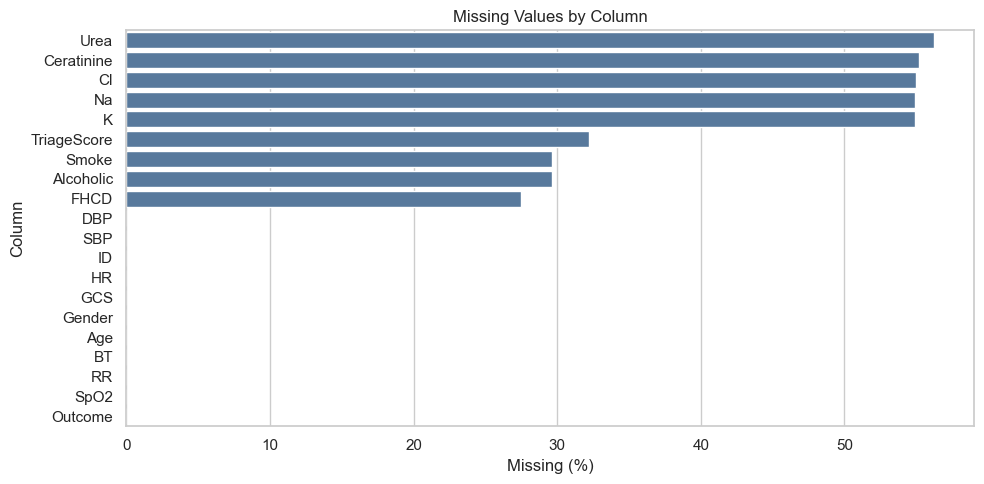

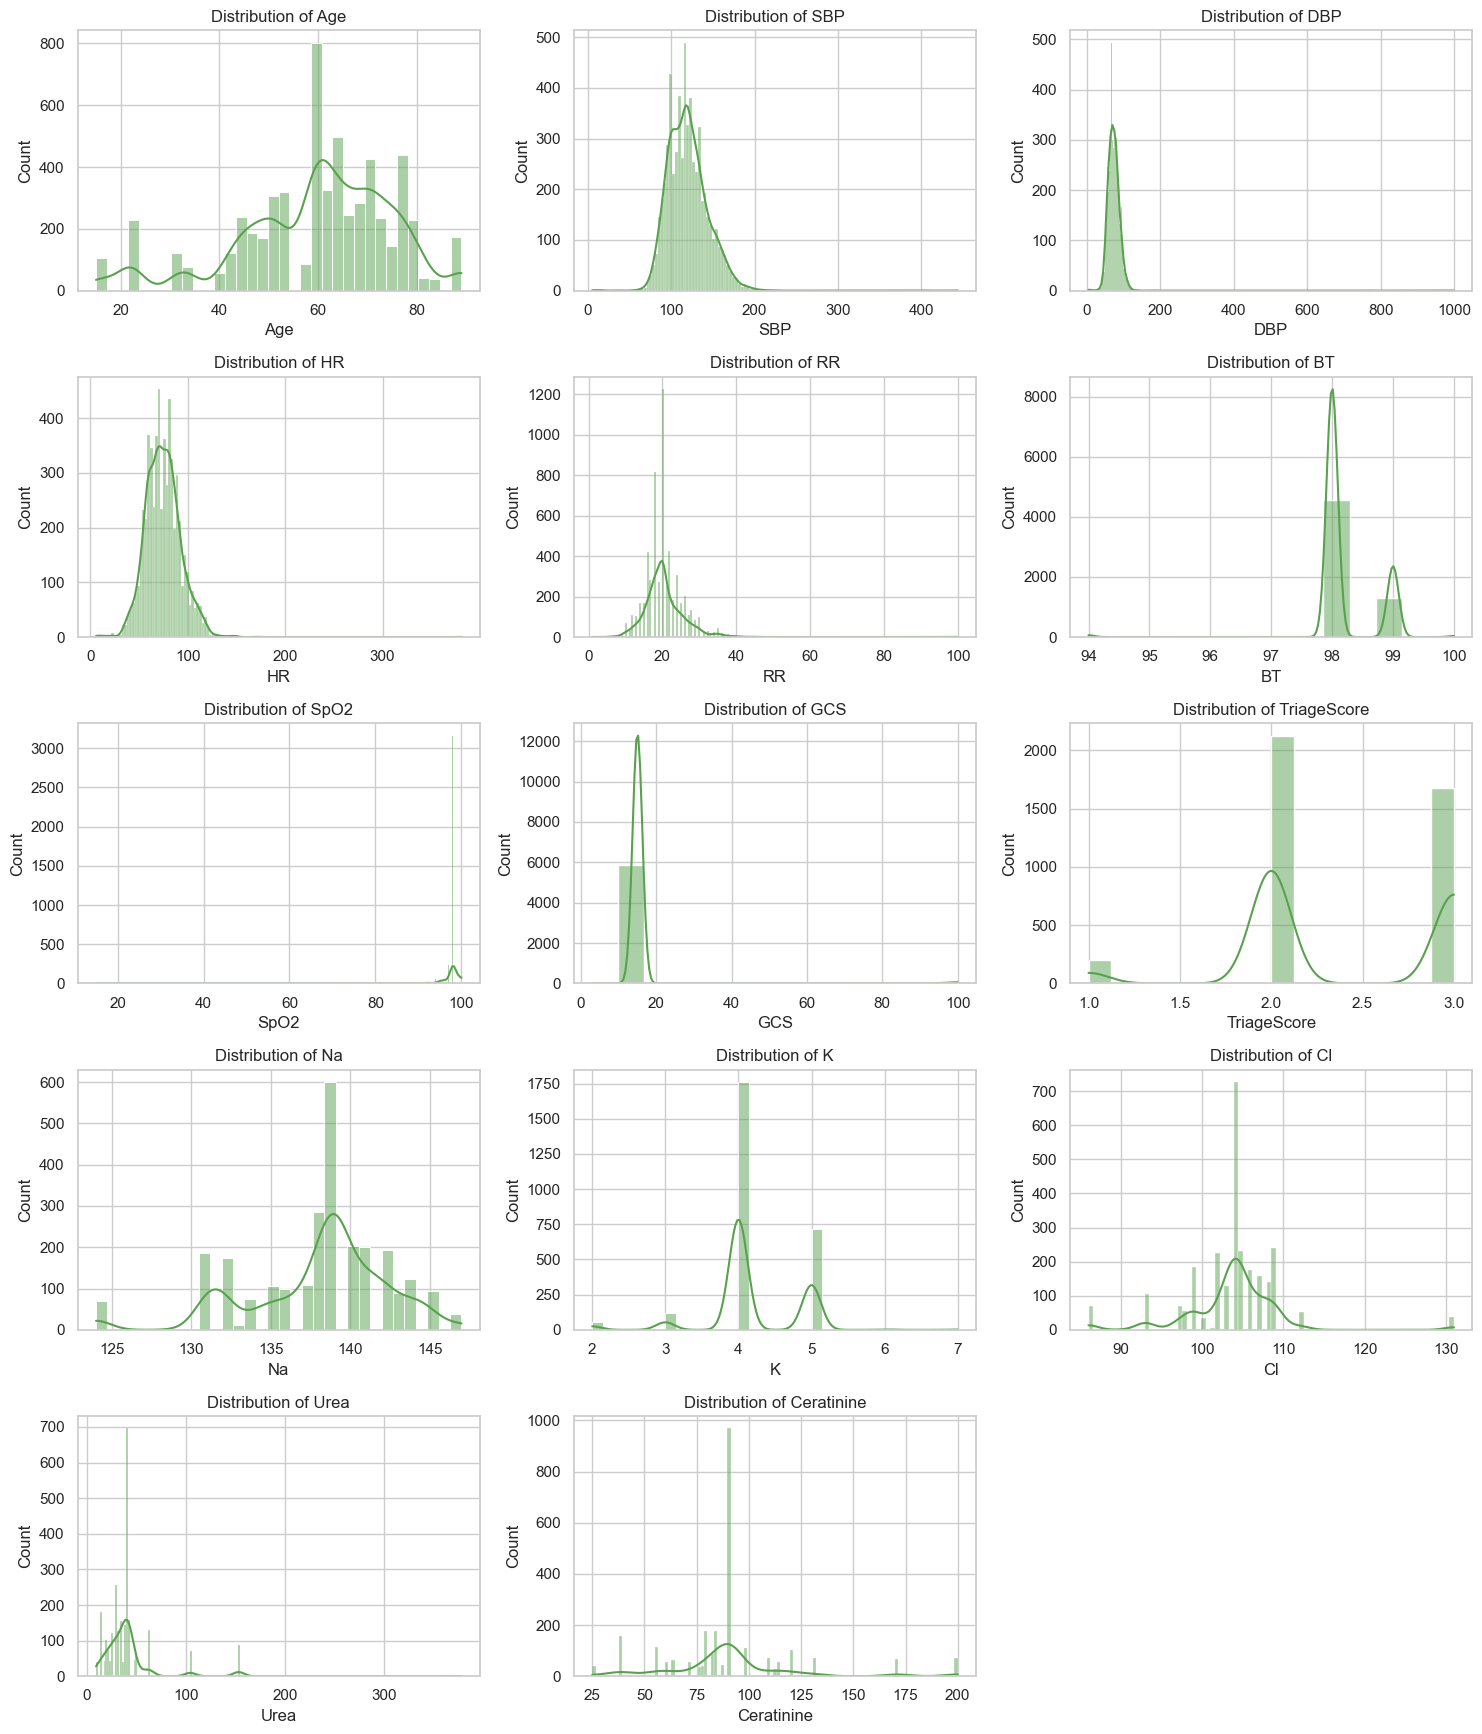

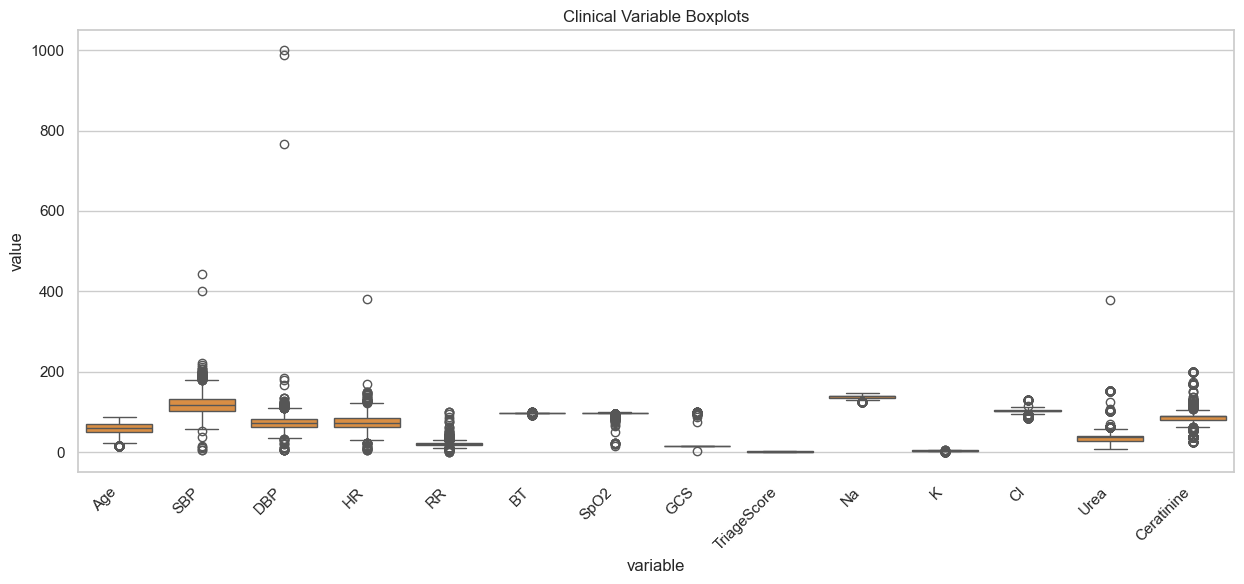

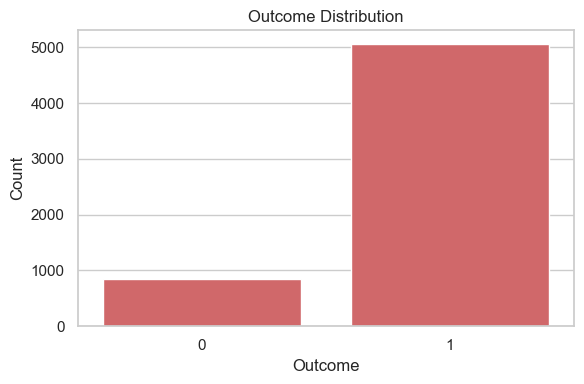

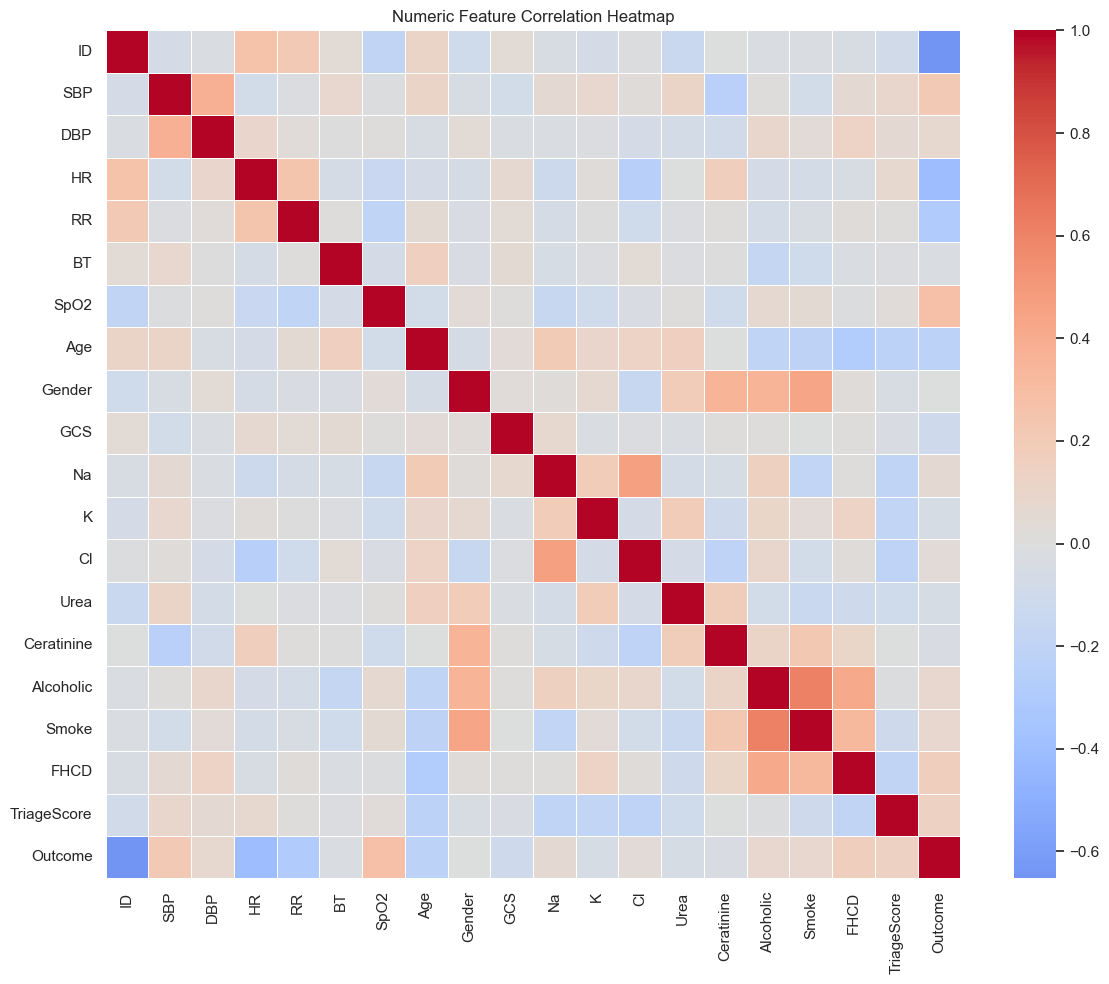

Saved figures:
- reports\figures\missing_values_by_column.png
- reports\figures\clinical_numeric_distributions.png
- reports\figures\clinical_variable_boxplots.png
- reports\figures\outcome_distribution.png
- reports\figures\numeric_correlation_heatmap.png


In [12]:
saved_figures = []

# Missingness bar chart
plt.figure(figsize=(10, 5))
missing_plot_data = missing_summary.sort_values("missing_percent", ascending=False)
sns.barplot(data=missing_plot_data, x="missing_percent", y="column", color="#4C78A8")
plt.title("Missing Values by Column")
plt.xlabel("Missing (%)")
plt.ylabel("Column")
plt.tight_layout()
path = FIGURES_DIR / "missing_values_by_column.png"
plt.savefig(path, dpi=150, bbox_inches="tight")
saved_figures.append(path)
plt.show()

# Histograms for clinical numeric variables
hist_columns = [col for col in clinical_variables if pd.api.types.is_numeric_dtype(df[col])]
if hist_columns:
    ncols = 3
    nrows = int(np.ceil(len(hist_columns) / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 3.5 * nrows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, hist_columns):
        sns.histplot(pd.to_numeric(df[col], errors="coerce").dropna(), kde=True, ax=ax, color="#59A14F")
        ax.set_title(f"Distribution of {col}")
    for ax in axes[len(hist_columns):]:
        ax.axis("off")
    fig.tight_layout()
    path = FIGURES_DIR / "clinical_numeric_distributions.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    saved_figures.append(path)
    plt.show()

# Boxplots for clinical numeric variables
if hist_columns:
    plot_df = df[hist_columns].apply(pd.to_numeric, errors="coerce").melt(var_name="variable", value_name="value")
    plt.figure(figsize=(max(12, len(hist_columns) * 0.9), 6))
    sns.boxplot(data=plot_df, x="variable", y="value", color="#F28E2B")
    plt.xticks(rotation=45, ha="right")
    plt.title("Clinical Variable Boxplots")
    plt.tight_layout()
    path = FIGURES_DIR / "clinical_variable_boxplots.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    saved_figures.append(path)
    plt.show()

# Outcome distribution, if present
if "Outcome" in df.columns:
    plt.figure(figsize=(6, 4))
    outcome_counts = df["Outcome"].value_counts(dropna=False).reset_index()
    outcome_counts.columns = ["Outcome", "count"]
    sns.barplot(data=outcome_counts, x="Outcome", y="count", color="#E15759")
    plt.title("Outcome Distribution")
    plt.xlabel("Outcome")
    plt.ylabel("Count")
    plt.tight_layout()
    path = FIGURES_DIR / "outcome_distribution.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    saved_figures.append(path)
    plt.show()

# Correlation heatmap for numeric variables
if len(numeric_columns) > 1:
    plt.figure(figsize=(12, 10))
    corr = df[numeric_columns].corr(numeric_only=True)
    sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.5)
    plt.title("Numeric Feature Correlation Heatmap")
    plt.tight_layout()
    path = FIGURES_DIR / "numeric_correlation_heatmap.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    saved_figures.append(path)
    plt.show()

print("Saved figures:")
for fig_path in saved_figures:
    print(f"- {fig_path.relative_to(PROJECT_ROOT)}")

## Save consolidated data quality summary CSV

In [13]:
summary = pd.DataFrame({"column": df.columns})
summary["dtype"] = summary["column"].map(df.dtypes.astype(str).to_dict())
summary["missing_count"] = summary["column"].map(df.isna().sum().to_dict()).astype(int)
summary["missing_percent"] = summary["column"].map((df.isna().mean() * 100).round(2).to_dict())
summary["unique_count"] = summary["column"].map(df.nunique(dropna=False).to_dict()).astype(int)
summary["duplicate_row_count_dataset"] = duplicate_row_count
summary["is_clinical_range_checked"] = summary["column"].isin(invalid_value_summary["column"])

invalid_lookup = invalid_value_summary.set_index("column") if not invalid_value_summary.empty else pd.DataFrame()
outlier_lookup = outlier_summary.set_index("column") if not outlier_summary.empty else pd.DataFrame()

summary["invalid_count"] = summary["column"].map(invalid_lookup["invalid_count"].to_dict() if not invalid_lookup.empty else {}).fillna(0).astype(int)
summary["invalid_percent"] = summary["column"].map(invalid_lookup["invalid_percent"].to_dict() if not invalid_lookup.empty else {}).fillna(0.0)
summary["clinical_min_allowed"] = summary["column"].map(invalid_lookup["min_allowed"].to_dict() if not invalid_lookup.empty else {})
summary["clinical_max_allowed"] = summary["column"].map(invalid_lookup["max_allowed"].to_dict() if not invalid_lookup.empty else {})
summary["clinical_unit"] = summary["column"].map(invalid_lookup["unit"].to_dict() if not invalid_lookup.empty else {})
summary["outlier_count_iqr"] = summary["column"].map(outlier_lookup["outlier_count"].to_dict() if not outlier_lookup.empty else {}).fillna(0).astype(int)
summary["outlier_percent_iqr"] = summary["column"].map(outlier_lookup["outlier_percent"].to_dict() if not outlier_lookup.empty else {}).fillna(0.0)

if id_column:
    summary["repeated_id_count_dataset"] = len(repeated_id_counts)
    summary["rows_with_repeated_ids_dataset"] = int(repeated_id_counts.sum())
else:
    summary["repeated_id_count_dataset"] = np.nan
    summary["rows_with_repeated_ids_dataset"] = np.nan

summary.to_csv(SUMMARY_PATH, index=False)
display(summary)
print(f"Saved summary CSV to {SUMMARY_PATH.relative_to(PROJECT_ROOT)}")

,column,dtype,missing_count,missing_percent,unique_count,duplicate_row_count_dataset,is_clinical_range_checked,invalid_count,invalid_percent,clinical_min_allowed,clinical_max_allowed,clinical_unit,outlier_count_iqr,outlier_percent_iqr,repeated_id_count_dataset,rows_with_repeated_ids_dataset
0,ID,int64,0,0.00,112,54,False,0,0.00,NaN,NaN,NaN,0,0.00,108,5902
1,SBP,int64,0,0.00,150,54,True,8,0.14,50.0,260.0,mmHg,70,1.19,108,5902
2,DBP,int64,0,0.00,111,54,True,21,0.36,30.0,160.0,mmHg,79,1.34,108,5902
3,HR,int64,0,0.00,123,54,True,14,0.24,20.0,250.0,beats/min,52,0.88,108,5902
4,RR,int64,0,0.00,59,54,True,15,0.25,5.0,60.0,breaths/min,333,5.64,108,5902
5,BT,int64,0,0.00,5,54,True,0,0.00,86.0,113.0,°F,1351,22.88,108,5902
6,SpO2,int64,0,0.00,32,54,True,0,0.00,0.0,100.0,%,1015,17.19,108,5902
7,Age,int64,0,0.00,44,54,True,0,0.00,0.0,120.0,years,106,1.79,108,5902
8,Gender,int64,0,0.00,2,54,False,0,0.00,NaN,NaN,NaN,0,0.00,108,5902
9,GCS,int64,0,0.00,13,54,True,48,0.81,3.0,15.0,score,49,0.83,108,5902


Saved summary CSV to reports\data_quality_summary.csv


## Raw data integrity check

In [15]:
# Confirm this notebook did not mutate the in-memory raw dataframe copy.
pd.testing.assert_frame_equal(df, df_raw)
print("Raw CSV was not modified by this notebook; all outputs are derived summaries.")

Raw CSV was not modified by this notebook; all outputs are derived summaries.
